In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.optimize import minimize

In [2]:
rodar_nm = False
resetar_banco = False

In [3]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_nm\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")

In [4]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phase = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

bins   = [0, 50, 100, 150, 200, 300, np.inf]
labels = ['0–50', '50–100', '100–150', '150–200', '200–300', '300+']
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']
columns = data[0].columns

for i in range(4):
    data[i]['phases'] = phase[i].values
    data[i]['AmplitudeRange'] = pd.cut(data[i]['AmplitudeSample(4)'], bins=bins, labels=labels, right=False)

# for i in range(len(data)):
#     peak_energy = (data[i].groupby('AmplitudeRange', observed=True)[columns].max().max(axis=1))
    
#     for faixa in peak_energy.index:
    
#                 idx = data[i]['AmplitudeRange'] == faixa
    
#                 data[i].loc[idx, columns] = (data[i].loc[idx, columns] / peak_energy[faixa])


columns = data[0].columns

In [5]:
def subtrai_estimada(sinalrecebido, resultado_neldermead):
    A = resultado_neldermead
    sample = sinalrecebido

    #Subtrai cada amplitude estimada do sinal recebido, considerando o padrão do sinal e ignorando a quarta amostra
    signalPattern = np.array([
            [A[0]*1.0    , A[1]*0.4524   , A[2]*0.0172   , 0             , 0             , 0             , 0],
            [A[0]*0.5633 , A[1]*1        , A[2]*0.4524   , A[3]*0.0172   , 0             , 0             , 0],
            [A[0]*0.1493 , A[1]*0.5633   , A[2]*1        , A[3]*0.4524   , A[4]*0.0172   , 0             , 0],
            [0           , 0             , 0             , 0             , 0             , 0             , 0],
            [0           , A[1]*0.0424   , A[2]*0.1493   , A[3]*0.5633   , A[4]*1        , A[5]*0.4524   , A[6]*0.0172],
            [0           , 0             , A[2]*0.0424   , A[3]*0.1493   , A[4]*0.5633   , A[5]*1        , A[6]*0.4524],
            [0           , 0             , 0             , A[3]*0.0424   , A[4]*0.1493   , A[5]*0.5633   , A[6]*1]
            ])
    
    for i in range(len(sinalrecebido)):
        sample = sample - signalPattern[i]
        #print(sample)
    
    return sample


In [6]:
def nelder_mead(df, tol):
    def cost_function(A):
        signalPattern = np.array([
                A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
                A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
                A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
                A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
                0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
                0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
                0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
                ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5

    def parada(xk):
            erro_atual = cost_function(xk)
            if erro_atual < tol:
                raise StopIteration  

    sample4 = [] #Valor da amplitude do quarto sample para a solução encontrada
    #fun_list = [] #Valor da função objetivo para a solução encontrada
    phase_estimated = [] #Valor da phase estimada para a solução encontrada

    b= [ -0.3085, 1.9086, 19.0859, 0.7363, -14.5817, -5.0529, -1.7877 ]

    for samples in df:
    
        res = minimize(cost_function, samples, method='Nelder-Mead', callback=parada, options={'maxiter': 700, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        subtraida = subtrai_estimada(samples, res.x)
        phase_estimada = 0
        for i in range(len(subtraida)):
            phase_estimada += subtraida[i]*b[i]
        phase_estimada = phase_estimada/res.x[3] 
        
        sample4.append(res.x[3])
        phase_estimated.append(phase_estimada)
        
        
    return sample4, phase_estimated

In [7]:
def save_nm(sample4, occ, phase, ns_list, amplitude, amplitude_range):
    path = f'.\\tests_nm\\results\\nm_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({                    
            'TrueAmplitude': amplitude,
            'EstimatedAmplitude': sample4,
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'AmplitudeRange': amplitude_range})
        
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({
            'TrueAmplitude': amplitude,
            'EstimatedAmplitude': sample4,
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'AmplitudeRange': amplitude_range
        })

    df.to_csv(f'.\\tests_nm\\results\\nm_{occ}.csv', index=False)

In [8]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_nm:
        k = 0
        for i in range(4):
            samples_data = np.array(data[i][columns[0:7]])
            amplitudes_data = np.array(data[i][columns[7]])
            phases_data = np.array(data[i]['phases'])
            range_data = np.array(data[i]['AmplitudeRange'])

            sample4, ns_list = nelder_mead(samples_data, tol=1)
            save_nm(sample4, occ_name[i], phases_data, ns_list, amplitudes_data, range_data)
            
            k +=1
            print(f'Occupancy {occ_name[i][3:]} and tolerance {1} done, lacking {4 - k} combinations')

In [9]:
run_algorithm(data)

In [10]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_nm\results\nm_occ0.2.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.5.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.7.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.9.csv'),
    ]
    return resultados

In [15]:
df = load_results()
dfiltrado = df[i][df[i]['EstimatedAmplitude'] < 50]
dfiltrado['EstimatedAmplitude'].mean()

np.float64(4.073363620384018)

-3.2540737587947457 48.708041071337036


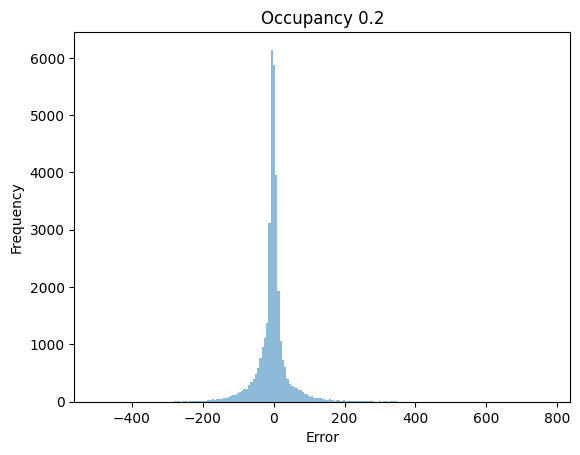

-2.1205826851835874 53.799971869813874


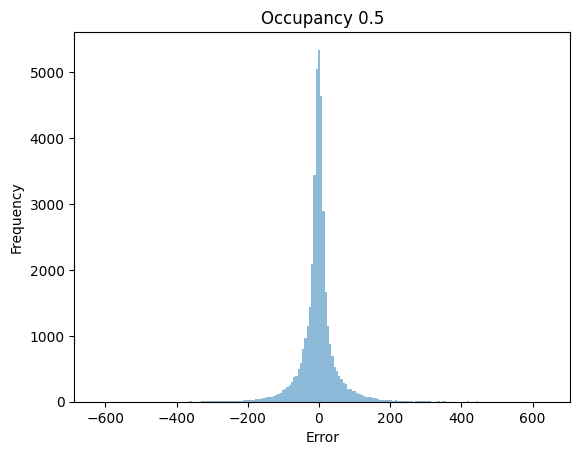

-1.9204903341053123 50.61730995759973


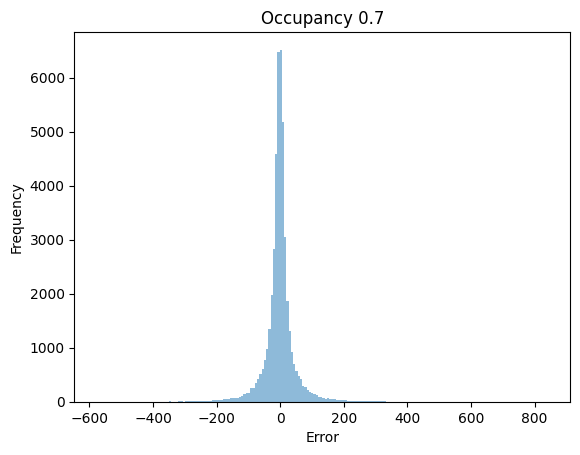

-2.2997075988829296 48.234077819695514


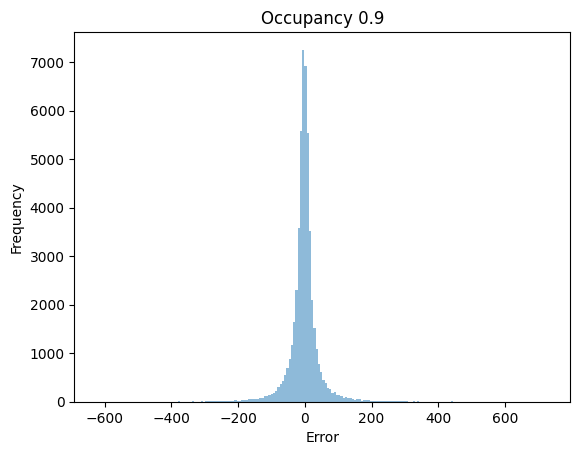

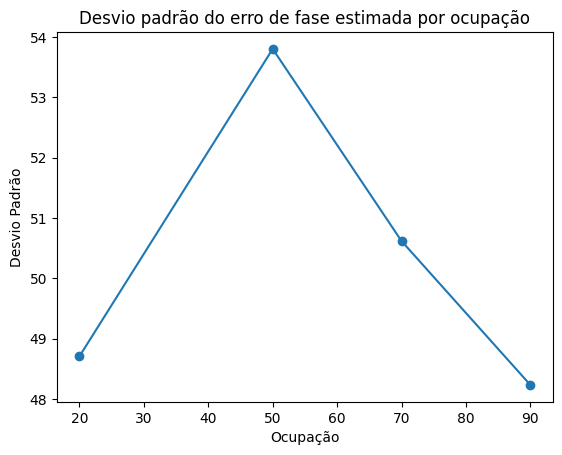

In [13]:
df = load_results()

std_errors = []
occ = [20, 50, 70, 90]


for i in range(len(df)):
    dfiltrado = df[i][df[i]['EstimatedAmplitude'] > 10]
    error = dfiltrado['TruePhase'] - dfiltrado['PhaseEstimada']
    #dfiltrado['Error'] = dfiltrado['Error']/dfiltrado['Error'].max()  # Normaliza o erro 
    plt.hist(error, bins=200, alpha=0.5)
    plt.xlabel('Error')
    plt.ylabel('Frequency')
    plt.title(f'Occupancy {occ_name[i][3:]}')
    print(error.mean(), error.std())
    plt.show()
    std_errors.append(error.std())

plt.plot(occ, std_errors, marker='o')
plt.title('Desvio padrão do erro de fase estimada por ocupação')
plt.xlabel('Ocupação')
plt.ylabel('Desvio Padrão')
plt.show()

In [28]:
df = load_results()
df[0]['Error'] = df[0]['TruePhase'] - df[0]['PhaseEstimada']
df[0].sort_values(by='AmplitudeRange')

,TrueAmplitude,EstimatedAmplitude,TruePhase,PhaseEstimada,AmplitudeRange,Error
0,0.0000,15.656926,0.0,12.413199,0–50,-12.413199
45235,0.0000,-33.763749,0.0,1.472183,0–50,-1.472183
45236,0.0000,34.593212,0.0,-2.313322,0–50,2.313322
45238,0.0000,73.032159,0.0,19.440461,0–50,-19.440461
45240,0.0000,-23.646240,0.0,97.468328,0–50,-97.468328
...,...,...,...,...,...,...
51009,98.5606,104.226948,-1.0,1.254311,50–100,-2.254311
35365,85.9031,95.175798,-5.0,4.622382,50–100,-9.622382
16816,56.1238,71.092675,1.0,-6.636927,50–100,7.636927
2892,70.2415,81.819807,-5.0,5.129445,50–100,-10.129445


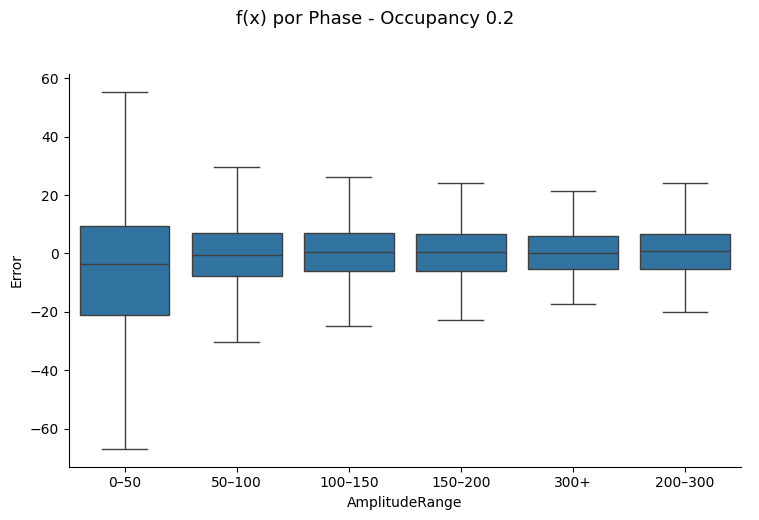

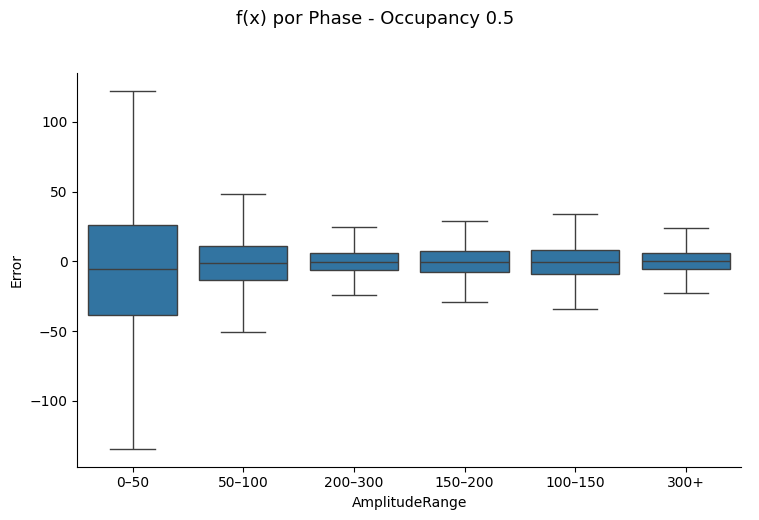

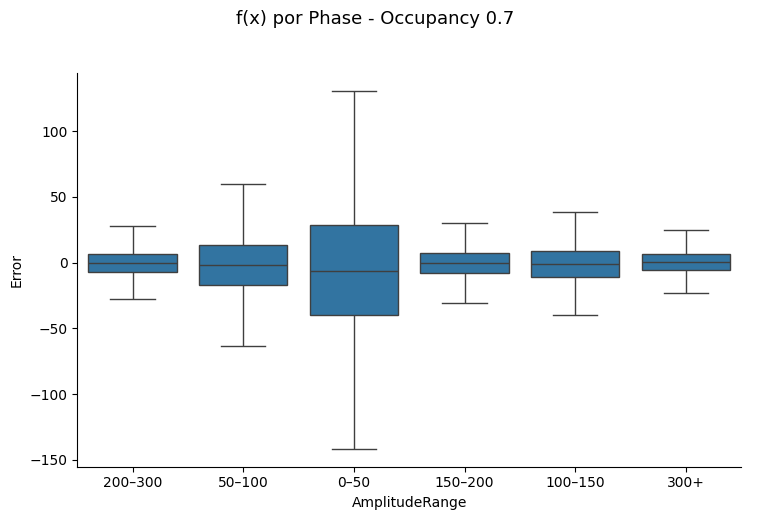

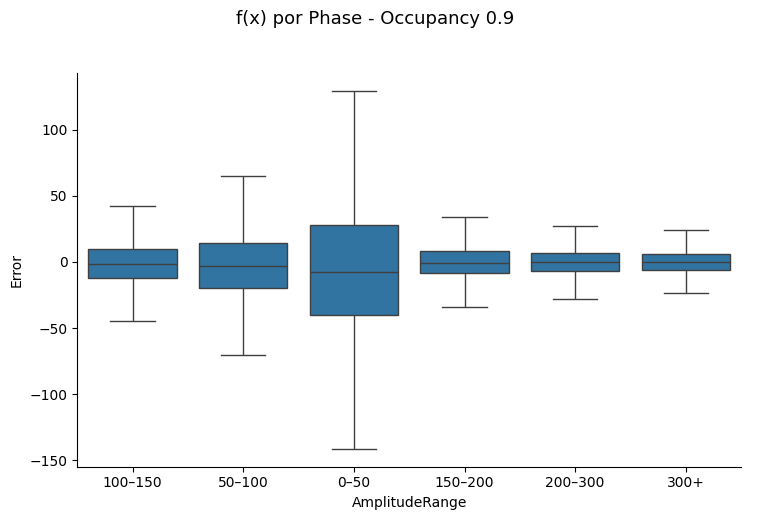

In [18]:
#faixa [0-10, 10-50, 50-100, 100-200, 200-500, 500+]
df = load_results()


for i in range(len(df)):    
    # Cria a coluna de Erro para facilitar o plot
    df[i] = df[i][df[i]['EstimatedAmplitude'] > 10] 
    df[i]['Error'] = df[i]['TruePhase'] - df[i]['PhaseEstimada']

    # plt.figure(figsize=(10, 6)) <-- Você pode remover esta linha

    g = sns.catplot(
        data=df[i],          # <-- CORRIGIDO: Passando o DataFrame da iteração atual
        x='AmplitudeRange',
        y='Error',           # <-- CORRIGIDO: Usando a nova coluna criada
        kind='box',
        height=5,
        aspect=1.5,
        sharey=False,
        showfliers=False
    )

    g.set_axis_labels('AmplitudeRange', 'Error')
    g.set_titles(col_template='E: {col_name}')
    
    g.fig.suptitle(
        f'f(x) por Phase - Occupancy {occ_name[i][3:]}',
        y=1.03, fontsize=13
    )
    
    plt.tight_layout()
    plt.show()